<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [22]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [23]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [24]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget


In [25]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

In [26]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

In [27]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

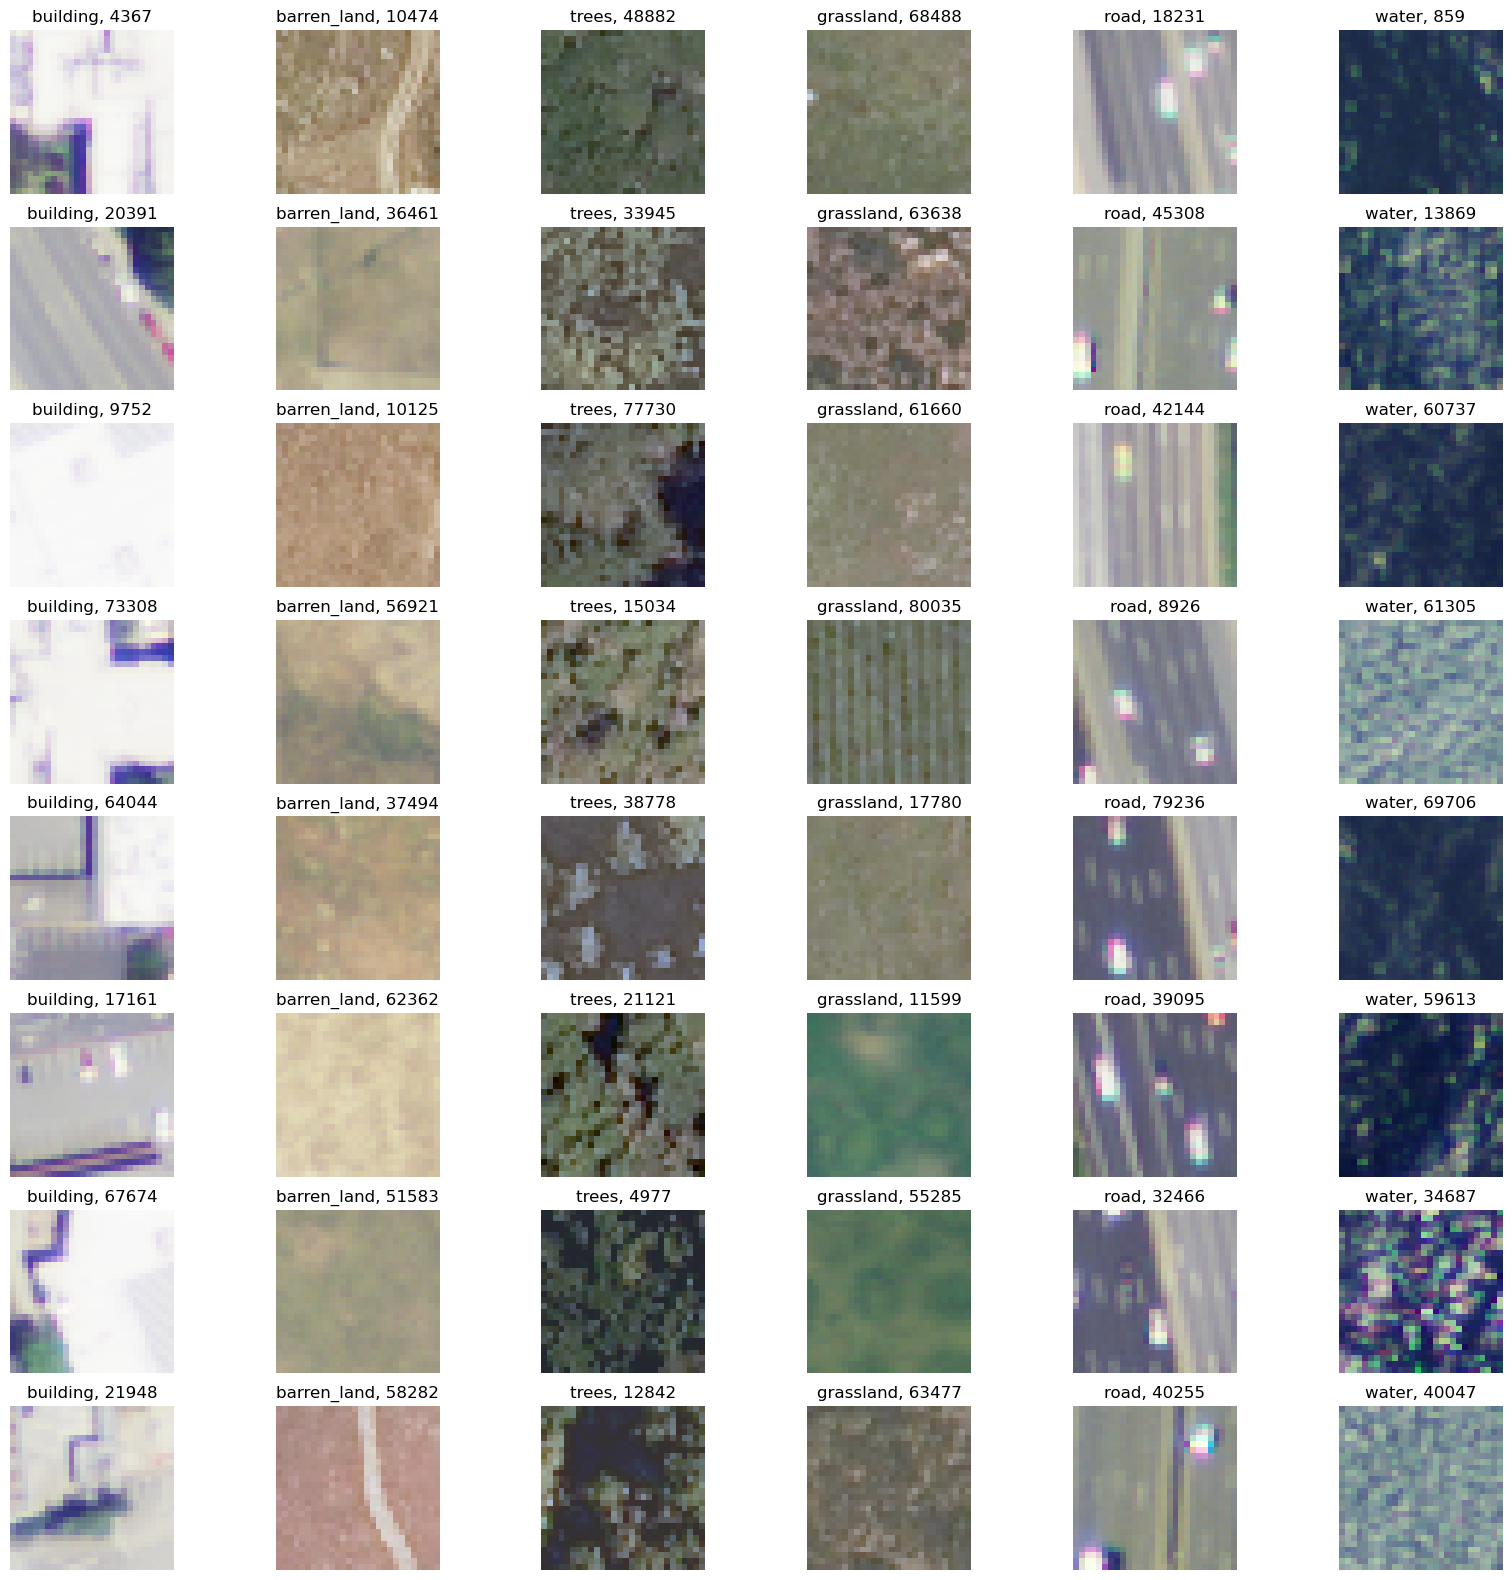

In [28]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [29]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Question:_ What is wrong with the above code?

In [30]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

In [31]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
77421,86,79,75,103,86,81,78,107,86,81,...,105,180,101,97,84,157,107,104,95,165
24623,92,93,114,20,90,92,117,20,90,92,...,158,57,148,145,147,43,127,124,143,33
2367,248,248,248,231,248,248,248,231,247,248,...,246,227,247,247,245,226,246,246,245,226
41384,176,171,163,66,172,169,161,67,172,169,...,160,141,178,162,151,145,171,163,148,151
76588,174,170,150,140,175,168,151,135,172,166,...,107,168,80,100,103,167,85,103,106,169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14246,157,172,154,199,144,161,148,201,139,157,...,135,184,178,167,134,184,189,176,146,183
3164,139,143,136,196,143,148,144,198,138,140,...,148,203,142,149,143,196,127,128,114,173
77287,110,118,106,159,96,99,80,144,107,109,...,52,24,24,28,63,19,25,26,58,20
5791,82,82,56,170,87,87,61,173,88,91,...,53,129,28,18,1,99,31,23,14,104


## Define and intialize random classifier from scikit-learn

In [32]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [33]:
rf.fit( train_X, train_y)

RandomForestClassifier()

## Check the prediction on the test set

In [34]:
rf.score(test_X, test_y)

0.935

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

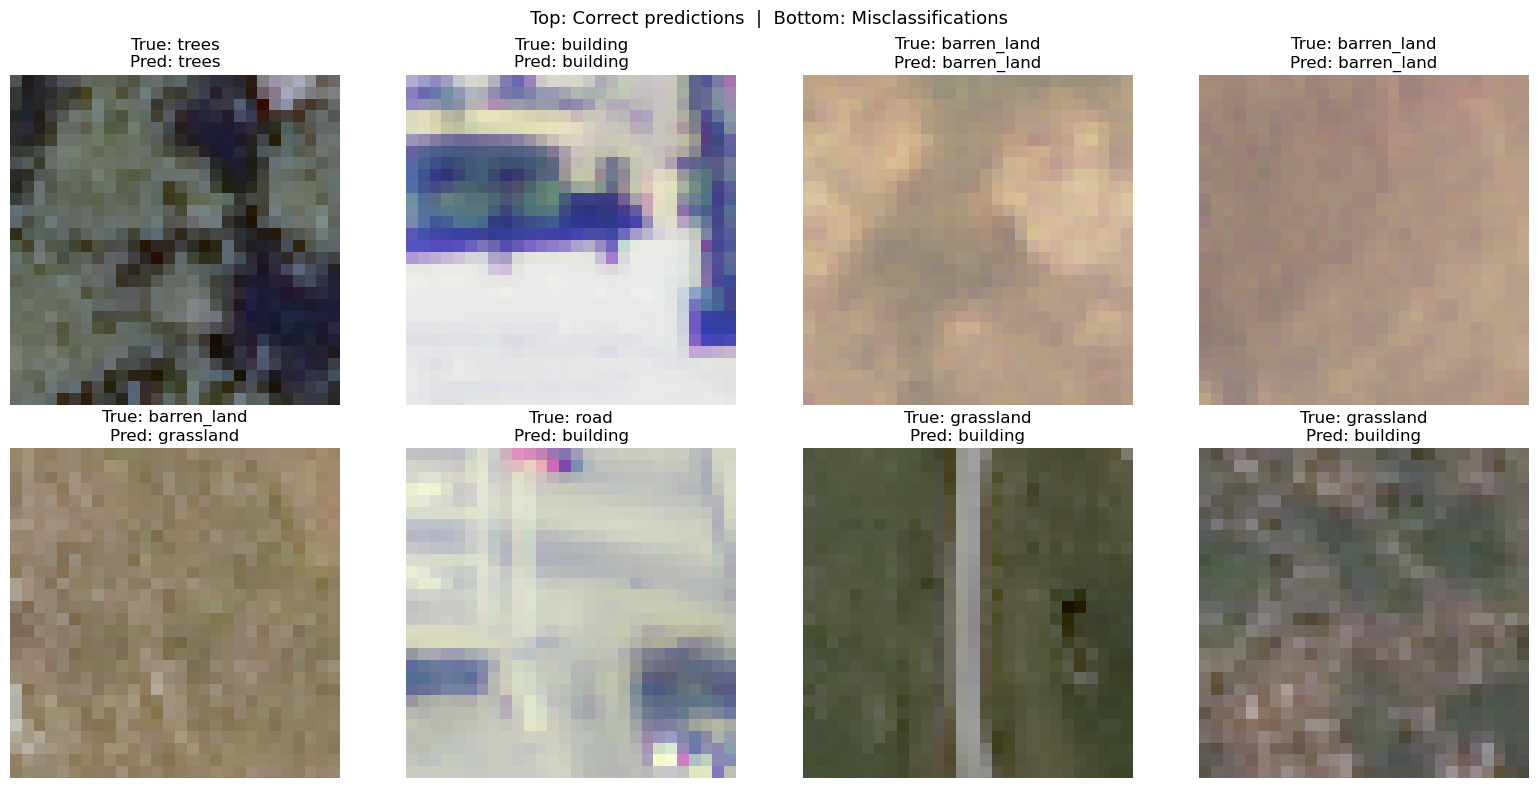

In [35]:
# Get predictions
pred_y = rf.predict(test_X)
true_int = np.argmax(test_y.values, axis=1)
pred_int = np.argmax(pred_y, axis=1)

correct_idx = np.where(true_int == pred_int)[0]
wrong_idx   = np.where(true_int != pred_int)[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Top: Correct predictions  |  Bottom: Misclassifications', fontsize=13)

for i, idx in enumerate(correct_idx[:4]):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    axes[0, i].imshow(img[..., :3].astype(np.uint8))
    axes[0, i].set_title(f'True: {labels[true_int[idx]]}\nPred: {labels[pred_int[idx]]}')
    axes[0, i].axis('off')

for i, idx in enumerate(wrong_idx[:4]):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    axes[1, i].imshow(img[..., :3].astype(np.uint8))
    axes[1, i].set_title(f'True: {labels[true_int[idx]]}\nPred: {labels[pred_int[idx]]}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Task 2.2 — Per-class accuracy and classification examples

Here I evaluate the accuracy separately for each class using `classification_report`, and visualize a few correctly and incorrectly classified images.

              precision    recall  f1-score   support

    building       0.80      0.99      0.89       100
 barren_land       0.99      0.96      0.97       100
       trees       0.95      0.96      0.96       100
   grassland       0.98      0.83      0.90       100
        road       0.98      0.92      0.95       100
       water       0.99      0.99      0.99       100

    accuracy                           0.94       600
   macro avg       0.95      0.94      0.94       600
weighted avg       0.95      0.94      0.94       600



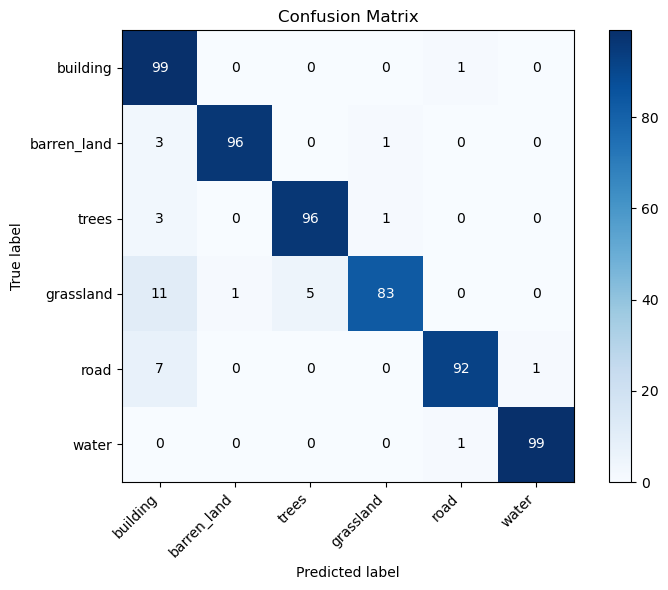

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# Per-class accuracy
print(classification_report(true_int, pred_int, target_names=labels))

# Confusion matrix
cm = confusion_matrix(true_int, pred_int)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

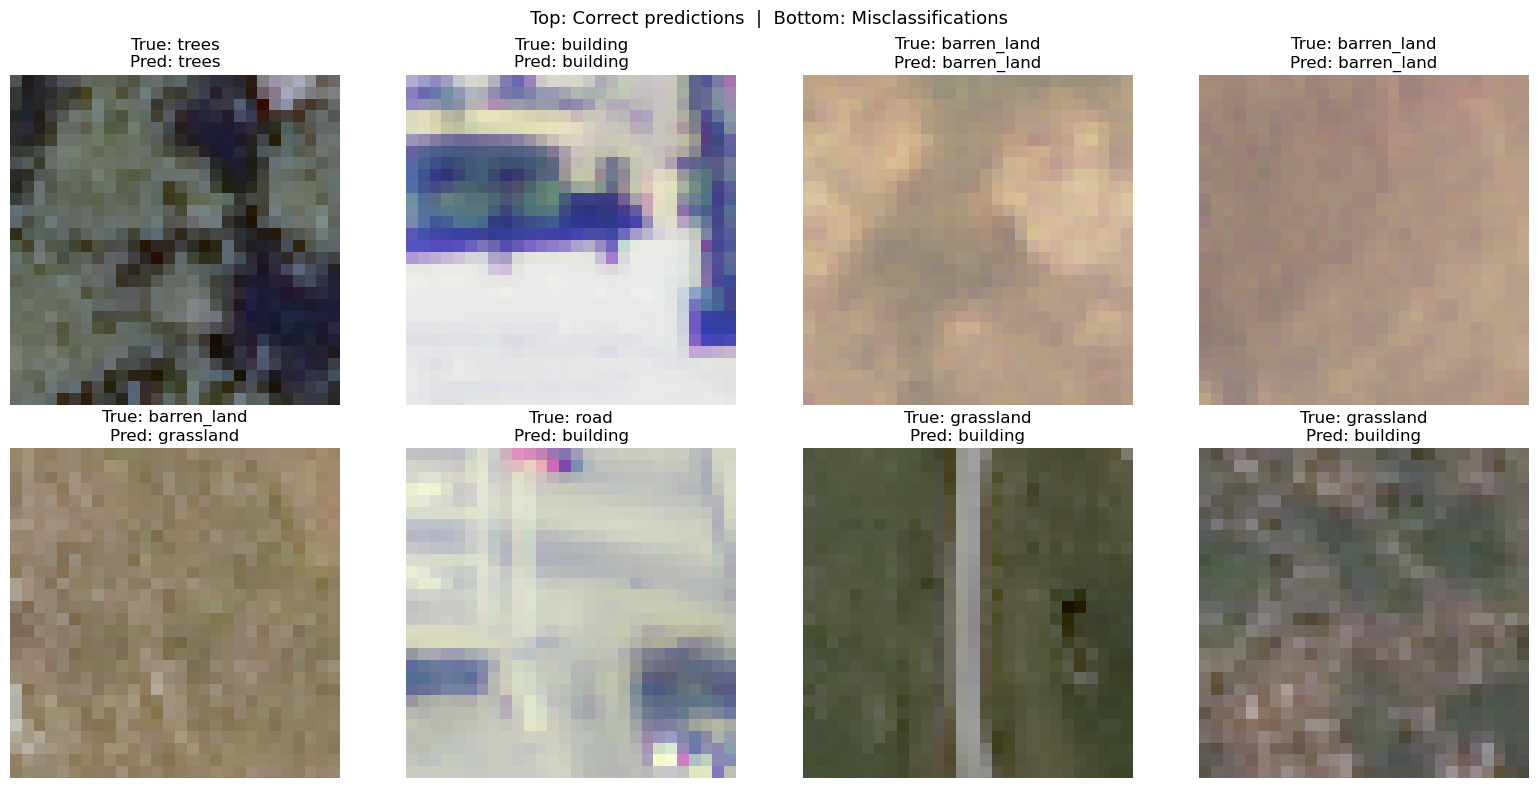

In [37]:
# Plot correct and misclassified examples (same predictions from above)
n = 4
fig, axes = plt.subplots(2, n, figsize=(16, 8))
fig.suptitle('Top: Correct predictions  |  Bottom: Misclassifications', fontsize=13)

for i, idx in enumerate(correct_idx[:n]):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    axes[0, i].imshow(img[..., :3].astype(np.uint8))
    axes[0, i].set_title(f'True: {labels[true_int[idx]]}\nPred: {labels[pred_int[idx]]}')
    axes[0, i].axis('off')

for i, idx in enumerate(wrong_idx[:n]):
    img = np.reshape(test_X.iloc[idx].values, (28, 28, 4))
    axes[1, i].imshow(img[..., :3].astype(np.uint8))
    axes[1, i].set_title(f'True: {labels[true_int[idx]]}\nPred: {labels[pred_int[idx]]}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Task 2.3 — RGB only (no NIR)

The data vector has 3136 columns — 4 channels stored sequentially, each occupying 784 values (28×28):
- R: 0–783, G: 784–1567, B: 1568–2351, NIR: 2352–3135

To use only RGB I select the first 2352 columns.

In [38]:
rgb_cols = list(range(2352))  # R + G + B

train_X_rgb = train_X.iloc[:, rgb_cols]
test_X_rgb  = test_X.iloc[:, rgb_cols]

rf_rgb = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rgb.fit(train_X_rgb, train_y)
score_rgb = rf_rgb.score(test_X_rgb, test_y)

rf_4ch = RandomForestClassifier(n_estimators=100, random_state=42)
rf_4ch.fit(train_X, train_y)
score_4ch = rf_4ch.score(test_X, test_y)

print(f'4-channel (full):  {score_4ch:.4f}')
print(f'RGB only:          {score_rgb:.4f}')
print(f'Drop:              {(score_4ch - score_rgb)*100:.2f} pp')

pred_rgb_int = np.argmax(rf_rgb.predict(test_X_rgb), axis=1)
print()
print(classification_report(true_int, pred_rgb_int, target_names=labels))

4-channel (full):  0.9417
RGB only:          0.9400
Drop:              0.17 pp

              precision    recall  f1-score   support

    building       0.84      0.98      0.90       100
 barren_land       0.98      0.96      0.97       100
       trees       0.93      0.96      0.95       100
   grassland       0.98      0.87      0.92       100
        road       0.98      0.91      0.94       100
       water       1.00      1.00      1.00       100

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



Removing NIR causes a small accuracy drop. This makes sense because the NIR channel is particularly useful for separating vegetation (trees, grassland) from urban surfaces — plant leaves strongly reflect NIR while roads and buildings do not.

## Task 2.4 — R, G, NIR only (no Blue)

Now I drop Blue instead of NIR to see which channel matters more.

In [39]:
r_cols   = list(range(0, 784))
g_cols   = list(range(784, 1568))
nir_cols = list(range(2352, 3136))
rgn_cols = r_cols + g_cols + nir_cols

train_X_rgn = train_X.iloc[:, rgn_cols]
test_X_rgn  = test_X.iloc[:, rgn_cols]

rf_rgn = RandomForestClassifier(n_estimators=100, random_state=42)
rf_rgn.fit(train_X_rgn, train_y)
score_rgn = rf_rgn.score(test_X_rgn, test_y)

print(f'4-channel (full):  {score_4ch:.4f}')
print(f'R+G+NIR:           {score_rgn:.4f}')
print(f'RGB only:          {score_rgb:.4f}')

pred_rgn_int = np.argmax(rf_rgn.predict(test_X_rgn), axis=1)
print()
print(classification_report(true_int, pred_rgn_int, target_names=labels))

4-channel (full):  0.9417
R+G+NIR:           0.9450
RGB only:          0.9400

              precision    recall  f1-score   support

    building       0.85      0.99      0.92       100
 barren_land       0.98      0.97      0.97       100
       trees       0.92      0.98      0.95       100
   grassland       0.98      0.86      0.91       100
        road       0.99      0.90      0.94       100
       water       1.00      1.00      1.00       100

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



R+G+NIR performs better than RGB — dropping Blue hurts less than dropping NIR. This confirms that NIR is the most informative channel, likely because of how differently vegetation and urban surfaces reflect near-infrared light.

## Task 2.5 — Hyperparameter: max_depth

I chose `max_depth` because it directly controls how complex each tree is allowed to become.

**Default:** `None` — trees grow until all leaves are pure.
**New value:** `max_depth=10`

My expectation: limiting depth should act as regularization. Individual trees will be shallower and less likely to overfit. Accuracy might drop slightly but the model should generalize better.

max_depth=5       ->  0.7900
max_depth=10      ->  0.9167
max_depth=20      ->  0.9400
max_depth=None    ->  0.9417


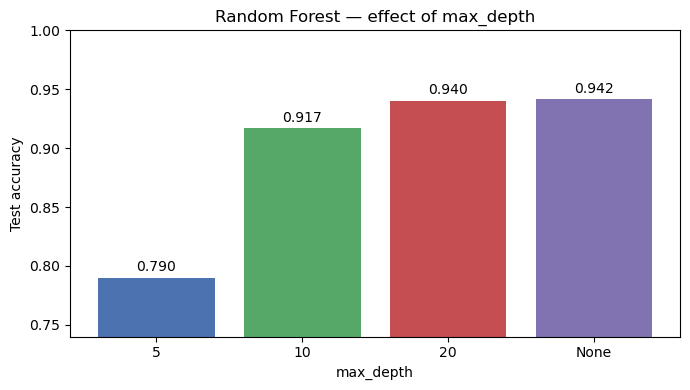


With max_depth=10 vs. unconstrained: 2.50 pp difference


In [40]:
depths = [5, 10, 20, None]
results = {}

for d in depths:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf_d.fit(train_X, train_y)
    score = rf_d.score(test_X, test_y)
    results[str(d)] = score
    print(f'max_depth={str(d):6s}  ->  {score:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
xlabels = [str(d) for d in depths]
scores  = [results[k] for k in xlabels]
bars = ax.bar(xlabels, scores, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_ylim(min(scores) - 0.05, 1.0)
ax.set_xlabel('max_depth')
ax.set_ylabel('Test accuracy')
ax.set_title('Random Forest — effect of max_depth')
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{s:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f'\nWith max_depth=10 vs. unconstrained: {(results["None"] - results["10"])*100:.2f} pp difference')